In [1]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [17]:
import os
print(os.listdir('AngularPS/processed_tensors/modelA'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [18]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/modelA/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/modelA/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/modelA/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 400, 'valid': 49, 'test': 50}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

警告：valid 数据集样本数量 (50) 与预期 (49) 不符！
torch.Size([400, 1, 20, 40])
torch.Size([400, 1])
训练集: 400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 50 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 50 样本, 数据形状 torch.Size([1, 20, 40])


定义CNN模型

In [19]:
import torch
import torch.nn as nn

class CNN_SingleParam(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CNN_SingleParam, self).__init__()
        
        # 输入形状: (batch, 1, 20, 40)
        
        # 第一块卷积
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # -> (32, 20, 40)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)                             # -> (32, 10, 20)
        
        # 第二块卷积
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> (64, 10, 20)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)                             # -> (64, 5, 10)
        
        # 展平
        self.flatten = nn.Flatten()
        
        # 全连接层
        # 特征维度：64 channels * 5 height * 10 width = 3200
        self.fc1     = nn.Linear(64 * 5 * 10, 256)
        self.relu3   = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_rate)
        
        # 输出层：单参数回归，只输出 1 个值
        self.fc_out  = nn.Linear(256, 1)
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc_out(x)          # 形状: (batch_size, 1)
        
        return x.squeeze(1)         # 返回 (batch_size,) 的一维张量，便于计算 MSELoss

定义训练函数

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError  # 如果你用了 torchmetrics

def r2_score(y_true, y_pred):
    """
    计算 R² 分数（标量标签版本）
    y_true, y_pred: Tensor of shape (N,)
    """
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_model(model, train_loader, valid_loader, epochs=200, patience=30, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    
    criterion = nn.MSELoss()                    # 均方误差
    mae_metric = MeanAbsoluteError().to(device) # MAE 指标
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        # ------------------- Training -------------------
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        train_samples = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)      # x: (B, 1, H, W), y: (B,) 或 (B,1)
            if y.dim() == 2:                       # 如果标签是 (B,1)，squeeze 成 (B,)
                y = y.squeeze(1)
                
            optimizer.zero_grad()
            output = model(x)                      # output: (B,)  (我们之前在模型里 squeeze 了)
            
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            
            batch_size = x.size(0)
            train_loss += loss.item() * batch_size
            train_mae += mae_metric(output, y).item() * batch_size
            train_samples += batch_size
        
        train_loss /= train_samples
        train_mae /= train_samples

        # ------------------- Validation -------------------
        model.eval()
        valid_loss = 0.0
        valid_mae = 0.0
        valid_samples = 0
        all_preds = []
        all_trues = []
        
        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                if y.dim() == 2:
                    y = y.squeeze(1)
                    
                output = model(x)
                
                loss = criterion(output, y)
                
                batch_size = x.size(0)
                valid_loss += loss.item() * batch_size
                valid_mae += mae_metric(output, y).item() * batch_size
                valid_samples += batch_size
                
                all_preds.append(output.cpu())
                all_trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae /= valid_samples
        
        # 计算整体 R²
        all_pred = torch.cat(all_preds)
        all_true = torch.cat(all_trues)
        valid_r2 = r2_score(all_true, all_pred).item()

        print(f'Epoch {epoch+1:3d}/{epochs} | '
              f'Train Loss: {train_loss:.6f} | Train MAE: {train_mae:.4f} | '
              f'Valid Loss: {valid_loss:.6f} | Valid MAE: {valid_mae:.4f} | '
              f'Valid R²: {valid_r2:.4f}')

        # ------------------- Early Stopping & Save Best -------------------
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), 'best_model_modelA.pt')
            early_stop_counter = 0
            print("  → New best model saved!")
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # 加载最佳模型
    print("Loading best model weights...")
    model.load_state_dict(torch.load('best_model_modelA.pt'))
    return model

定义测试函数

In [22]:
import torch
import torch.nn as nn
from torchmetrics import MeanAbsoluteError  # 如果你用了 torchmetrics

def r2_score(y_true, y_pred):
    """
    计算 R² 分数（单参数版本）
    y_true, y_pred: Tensor of shape (N,)
    """
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def test_model(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    criterion = nn.MSELoss()
    mae_metric = MeanAbsoluteError().to(device)
    
    test_loss = 0.0
    test_mae = 0.0
    test_samples = 0
    
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            
            # 如果标签是 (B, 1)，squeeze 成 (B,)
            if y.dim() == 2:
                y = y.squeeze(1)
                
            output = model(x)  # output: (B,)  —— 因为模型里已经 squeeze 了
            
            loss = criterion(output, y)
            
            batch_size = x.size(0)
            test_loss += loss.item() * batch_size
            test_mae += mae_metric(output, y).item() * batch_size
            test_samples += batch_size
            
            # 收集预测和真实值（用于 R² 计算）
            all_preds.append(output.cpu())
            all_trues.append(y.cpu())
    
    # 计算平均指标
    test_loss /= test_samples
    test_mae /= test_samples
    
    # 计算整体 R²
    all_pred = torch.cat(all_preds)
    all_true = torch.cat(all_trues)
    test_r2 = r2_score(all_true, all_pred).item()
    
    # 转为 numpy（方便后续绘图或保存）
    predictions = all_pred.numpy()   # shape: (N,)
    trues = all_true.numpy()         # shape: (N,)

    print(f'Test Loss: {test_loss:.6f} | '
          f'Test MAE: {test_mae:.4f} | '
          f'Test R²: {test_r2:.4f}')

    return test_loss, test_mae, test_r2, predictions, trues

主程序：加载数据、训练和测试

In [24]:
import torch
import numpy as np

# ------------------- 1. 加载数据 -------------------
# 假设你已经定义了 load_data() 函数，返回三个 DataLoader
# train_loader: 训练集
# valid_loader: 验证集
# test_loader:  测试集
train_loader, valid_loader, test_loader = load_data()

print(f"数据加载完成："
      f"Train {len(train_loader.dataset)} | "
      f"Valid {len(valid_loader.dataset)} | "
      f"Test {len(test_loader.dataset)}")

# ------------------- 2. 初始化模型 -------------------
model = CNN_SingleParam(dropout_rate=0.3)  # 使用我们之前定义的单参数模型

# ------------------- 3. 训练模型 -------------------
model = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    epochs=200,        # 单参数任务通常收敛更快，可适当增加
    patience=30,
    lr=0.001
)

# 注意：train_model 内部已经自动保存并加载了最佳模型（best_model_modelA.pt）
# 所以这里不需要再手动 load

# ------------------- 4. 测试模型 -------------------
test_loss, test_mae, test_r2, predictions, trues = test_model(model, test_loader)

# predictions 和 trues 当前是归一化后的值（numpy array, shape: (N,)）

# ------------------- 5. 反归一化到原始 klw 尺度 -------------------
label_stats = torch.load('AngularPS/processed_tensors/modelA/label_stats.pt')
mean = label_stats['mean'].item()   # 标量
std = label_stats['std'].item()     # 标量

# 反归一化
predictions_original = predictions * std + mean
trues_original = trues * std + mean

# 计算原始尺度下的 MAE
mae_original = np.mean(np.abs(predictions_original - trues_original))

print("\n" + "="*60)
print("测试集最终结果（原始 klw 尺度）")
print("="*60)
print(f"Test Loss (归一化): {test_loss:.6f}")
print(f"Test MAE  (归一化): {test_mae:.4f}")
print(f"Test R²   (归一化): {test_r2:.4f}")
print(f"Test MAE  (原始 klw): {mae_original:.4f}")
print("="*60)

# ------------------- 6. 打印前几个样本的预测与真实值 -------------------
print("\n前 10 个测试样本预测 vs 真实值（klw）：")
print("样本\t预测值\t\t真实值\t\t误差")
print("-" * 50)
n_show = min(10, len(predictions_original))
for i in range(n_show):
    pred = predictions_original[i]
    true = trues_original[i]
    error = pred - true
    print(f"{i+1:2d}\t{pred:.4f}\t\t{true:.4f}\t\t{error:+.4f}")

print("\n测试完成！")

警告：valid 数据集样本数量 (50) 与预期 (49) 不符！
torch.Size([400, 1, 20, 40])
torch.Size([400, 1])
训练集: 400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 50 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 50 样本, 数据形状 torch.Size([1, 20, 40])
数据加载完成：Train 400 | Valid 50 | Test 50
Using device: cuda
Epoch   1/200 | Train Loss: 1.418517 | Train MAE: 0.8852 | Valid Loss: 0.826309 | Valid MAE: 0.7811 | Valid R²: 0.2034
  → New best model saved!
Epoch   2/200 | Train Loss: 0.662989 | Train MAE: 0.6433 | Valid Loss: 0.795214 | Valid MAE: 0.7900 | Valid R²: 0.2334
  → New best model saved!
Epoch   3/200 | Train Loss: 0.368987 | Train MAE: 0.4981 | Valid Loss: 0.199663 | Valid MAE: 0.3909 | Valid R²: 0.8075
  → New best model saved!
Epoch   4/200 | Train Loss: 0.263589 | Train MAE: 0.3962 | Valid Loss: 0.278479 | Valid MAE: 0.4631 | Valid R²: 0.7315
Epoch   5/200 | Train Loss: 0.272484 | Train MAE: 0.4081 | Valid Loss: 0.169233 | Valid MAE: 0.3046 | Valid R²: 0.8369
  → New best model saved!
Epoch   6/200 | Train Loss: 0.34861

测试集参数估计可视化

警告：valid 数据集样本数量 (50) 与预期 (49) 不符！
torch.Size([400, 1, 20, 40])
torch.Size([400, 1])
训练集: 400 样本, 数据形状 torch.Size([1, 20, 40])
验证集: 50 样本, 数据形状 torch.Size([1, 20, 40])
测试集: 50 样本, 数据形状 torch.Size([1, 20, 40])
Test Loss: 0.073685 | Test MAE: 0.2011 | Test R²: 0.9357
测试集样本数: 50
反归一化完成 → klw 范围: [0.000, 7.000]


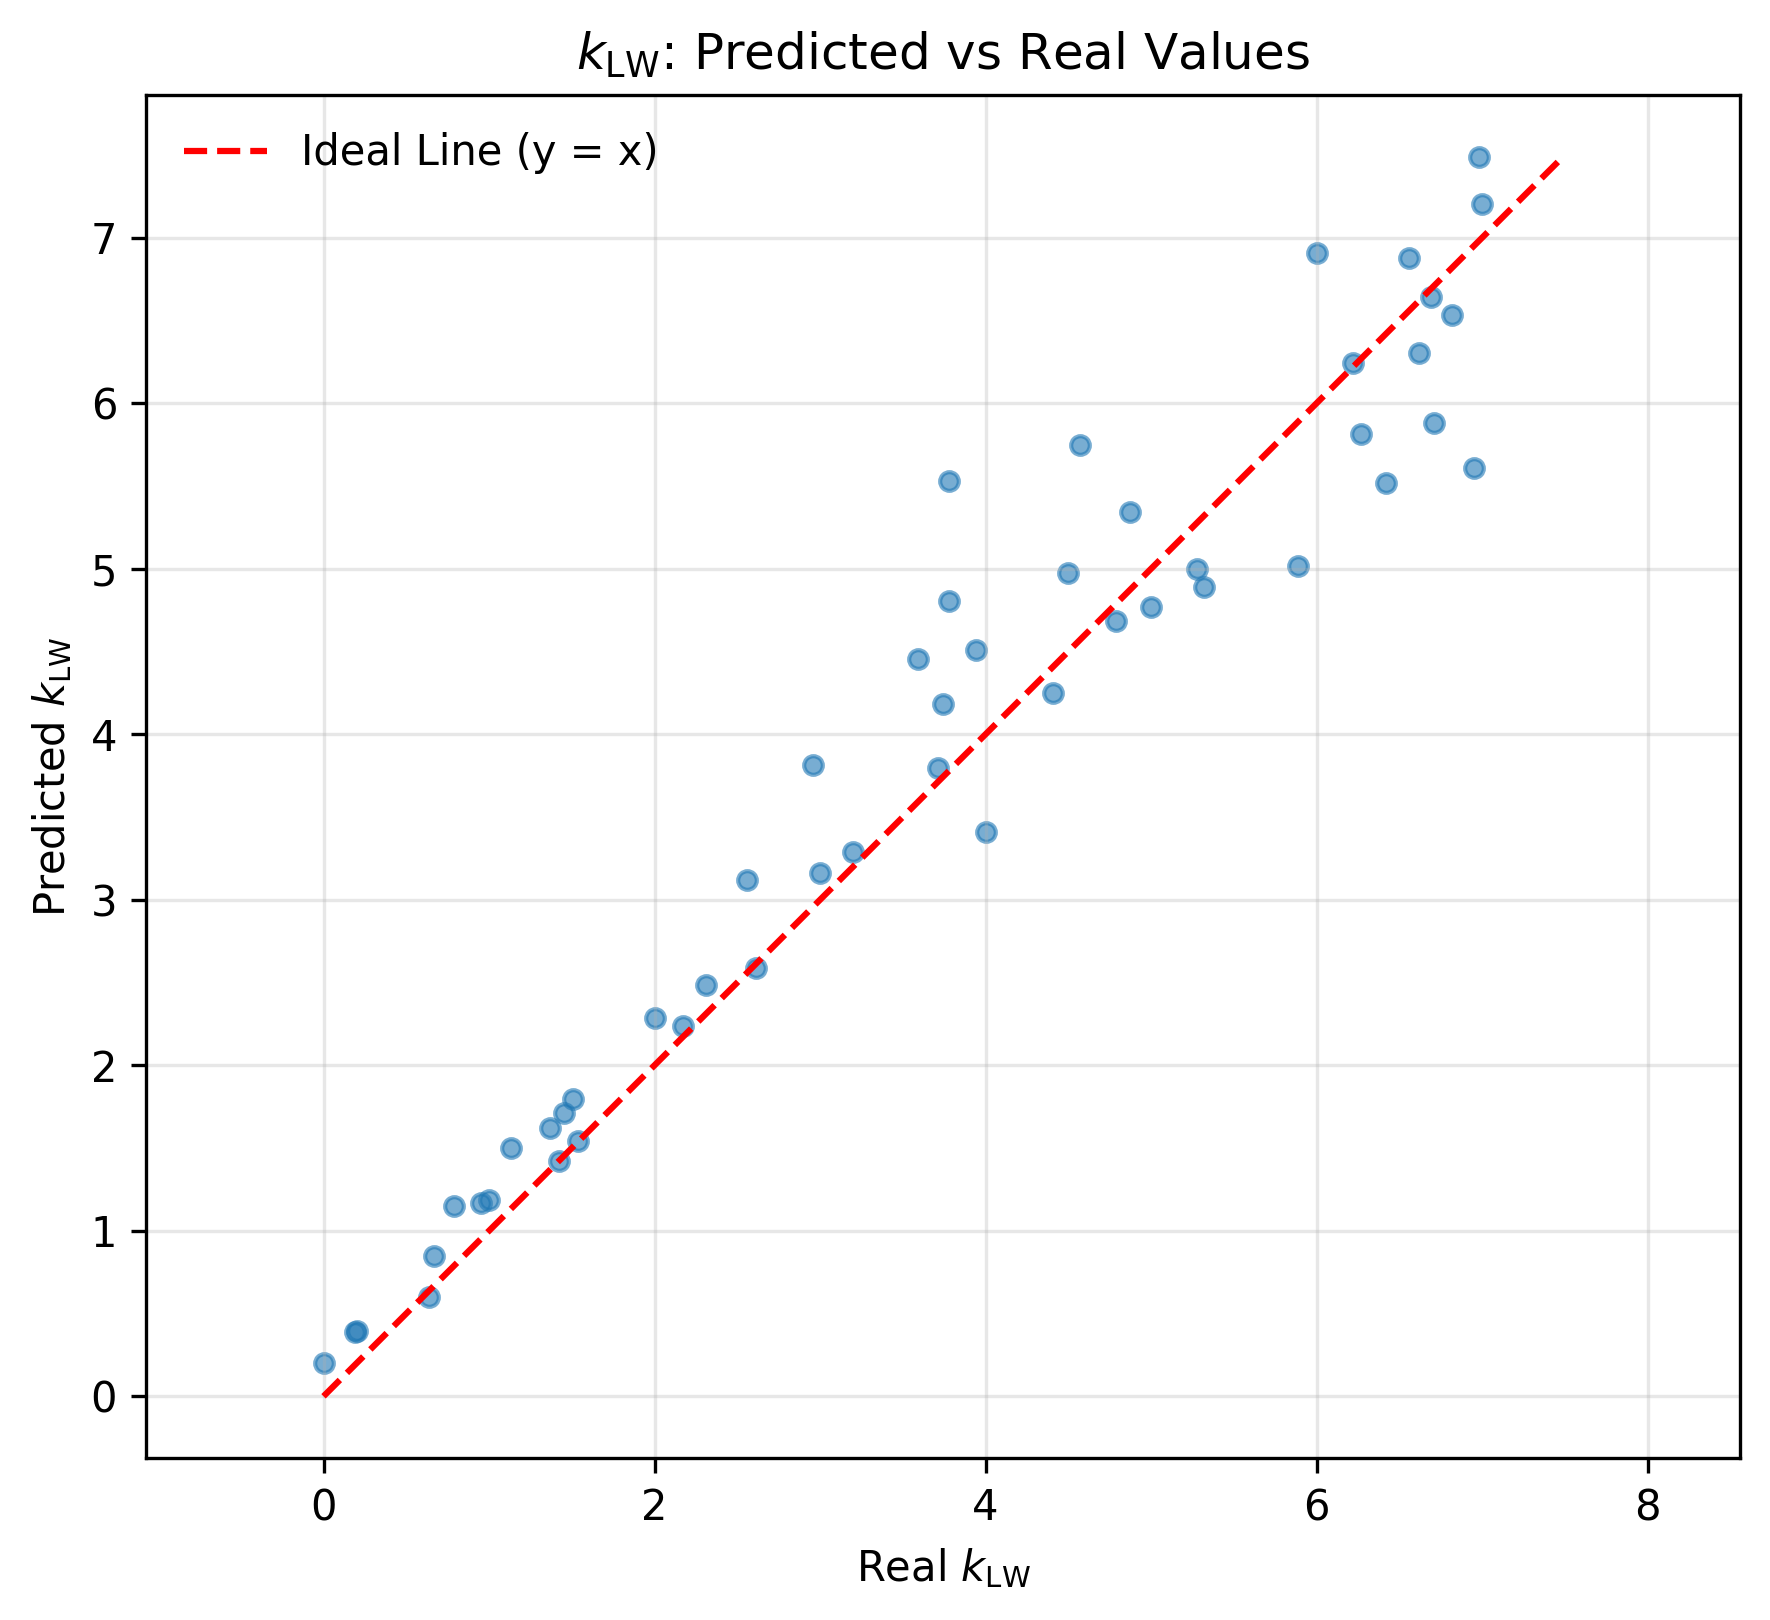

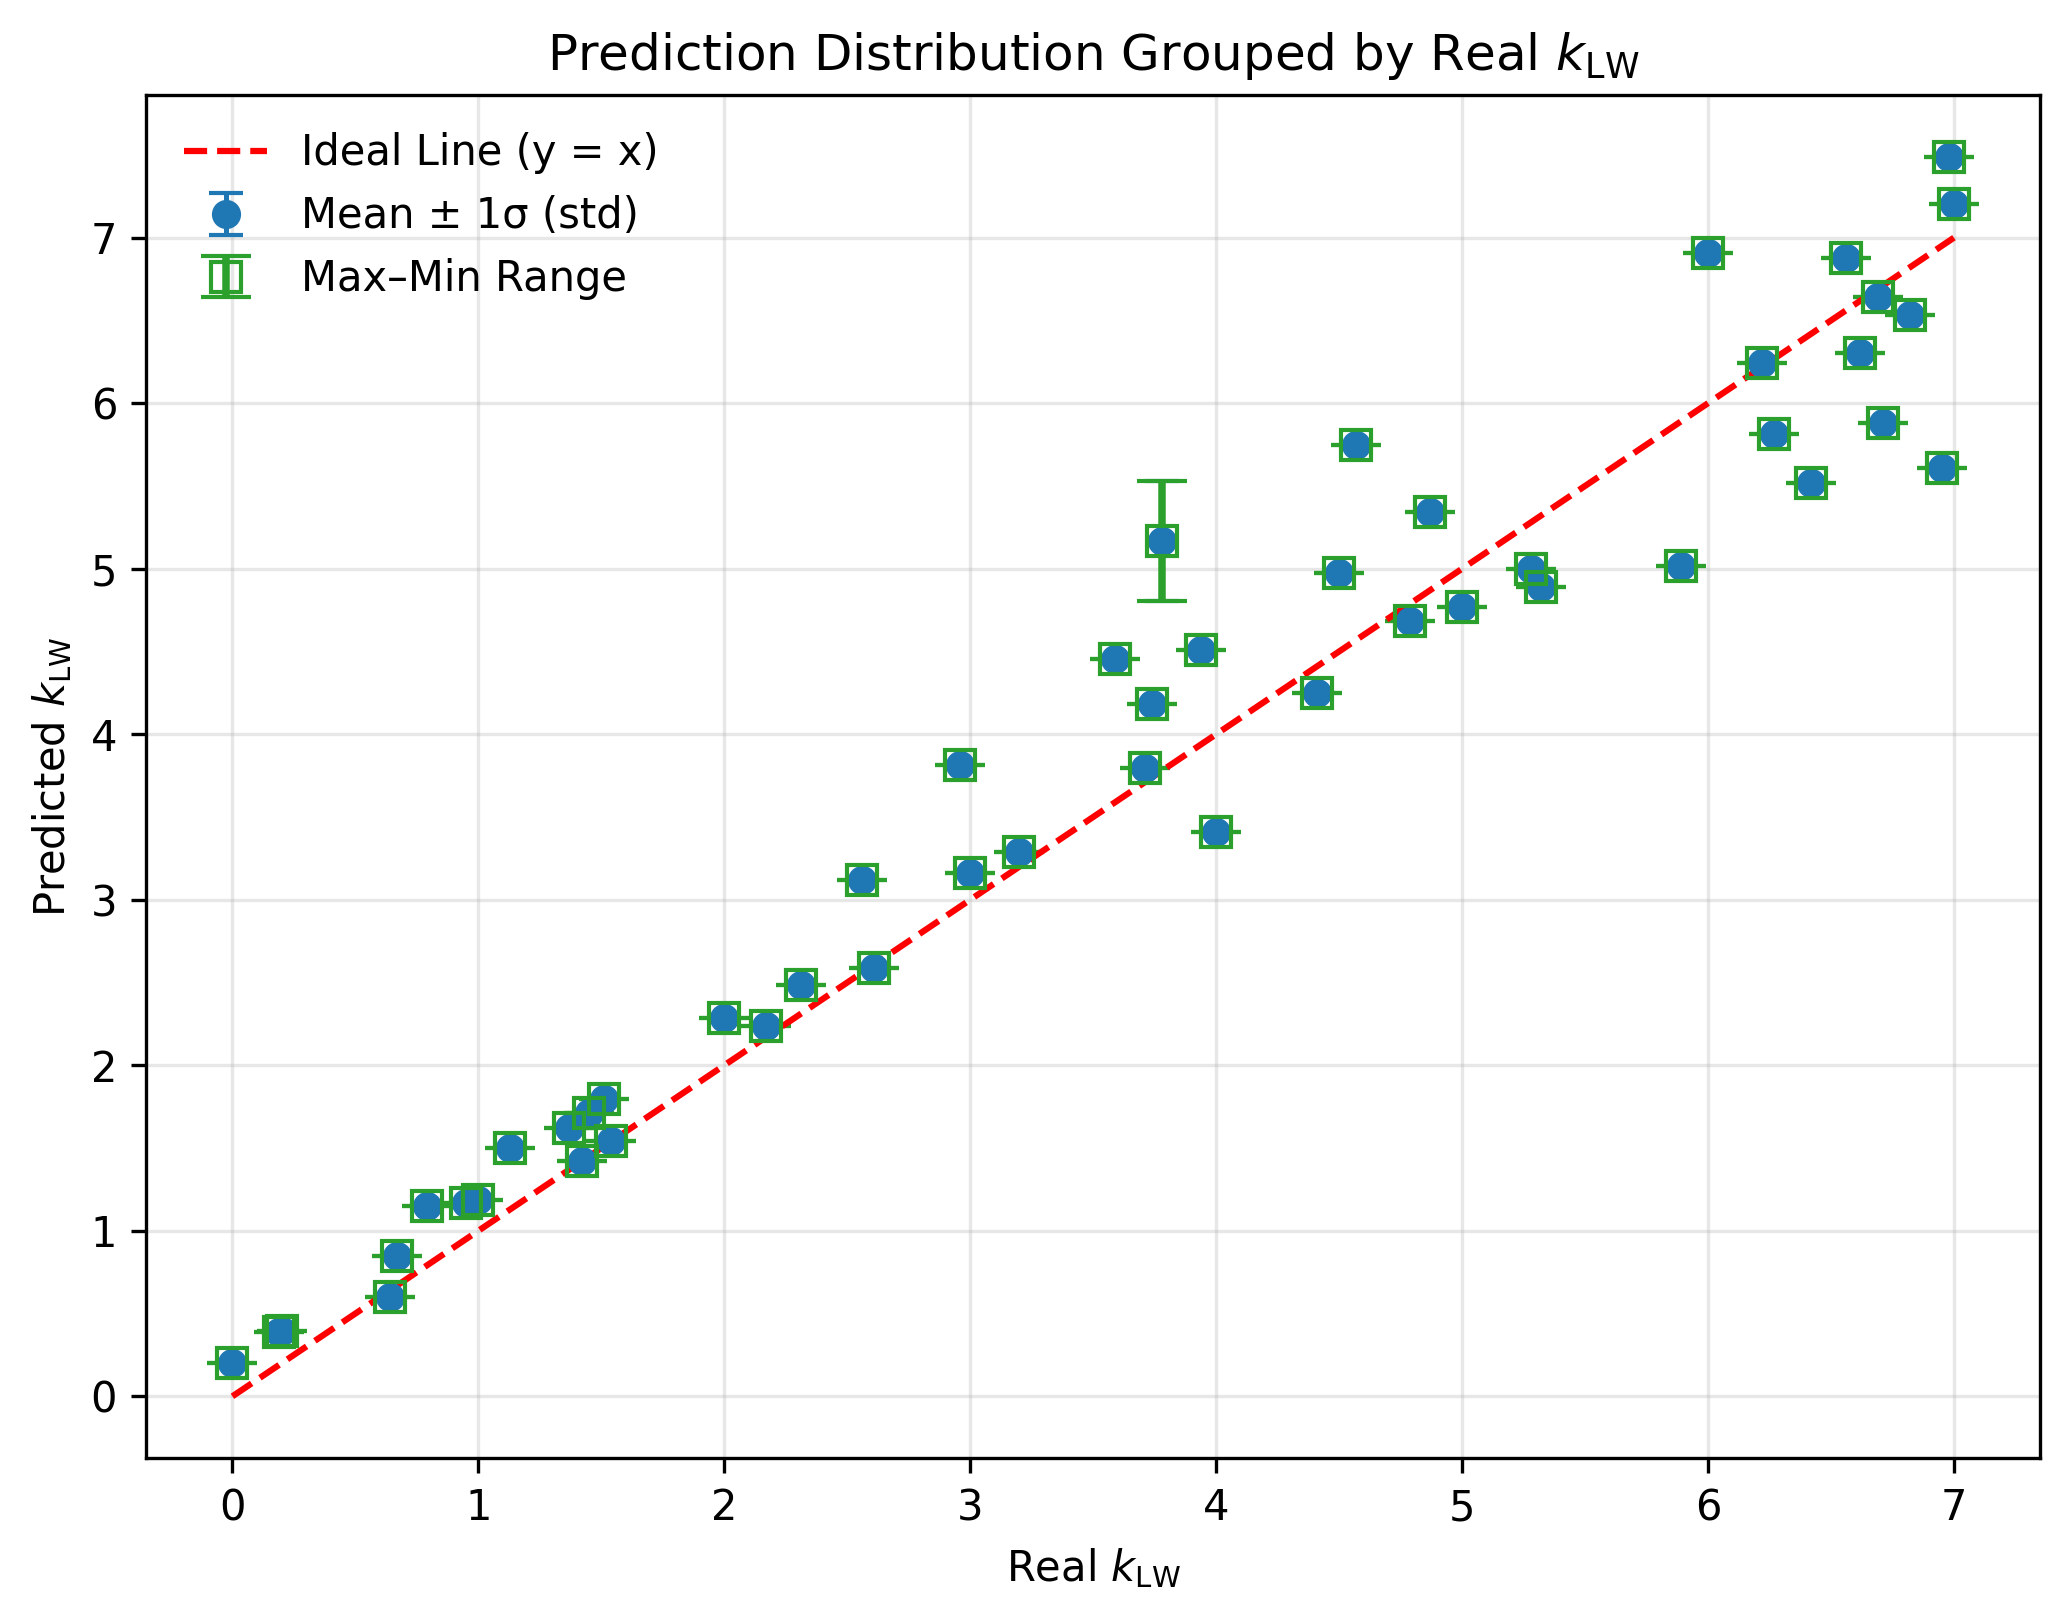


=== k_LW 分组预测统计 ===
Real k_LW	Samples	Mean Pred	±1σ Range		Max-Min Range
----------------------------------------------------------------------
0.000		1		0.2011		(single point)		(single point)
0.190		1		0.3867		(single point)		(single point)
0.200		1		0.3967		(single point)		(single point)
0.640		1		0.6018		(single point)		(single point)
0.670		1		0.8449		(single point)		(single point)
0.790		1		1.1481		(single point)		(single point)
0.950		1		1.1651		(single point)		(single point)
1.000		1		1.1831		(single point)		(single point)
1.130		1		1.5020		(single point)		(single point)
1.370		1		1.6238		(single point)		(single point)
1.420		1		1.4237		(single point)		(single point)
1.450		1		1.7114		(single point)		(single point)
1.510		1		1.7960		(single point)		(single point)
1.540		1		1.5401		(single point)		(single point)
2.000		1		2.2857		(single point)		(single point)
2.170		1		2.2356		(single point)		(single point)
2.310		1		2.4861		(single point)		(single point)
2.560		1		3.1186		(sin

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==================== 学术论文字体和样式（全局配置） ====================
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['figure.dpi'] = 300  # 高分辨率默认

# ==================== 加载测试数据 ====================
_, _, test_loader = load_data()

# ==================== 初始化模型并加载最佳权重 ====================
model = CNN_SingleParam(dropout_rate=0.3)  # 使用单参数模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model_modelA.pt'))  # 注意文件名更新
model.eval()

# ==================== 测试并获取归一化后的预测值 ====================
test_loss, test_mae, test_r2, predictions_norm, trues_norm = test_model(model, test_loader)
# predictions_norm, trues_norm: numpy array, shape (N,)

# ==================== 反归一化到原始 klw 尺度 ====================
label_stats = torch.load('AngularPS/processed_tensors/modelA/label_stats.pt')
mean = label_stats['mean'].item()   # 标量
std = label_stats['std'].item()     # 标量

predictions = predictions_norm * std + mean
trues = trues_norm * std + mean

print(f"测试集样本数: {len(trues)}")
print(f"反归一化完成 → klw 范围: [{trues.min():.3f}, {trues.max():.3f}]")

# ==================== 1. 散点图：预测值 vs 真实值 ====================
plt.figure(figsize=(6, 5.5))

plt.scatter(trues, predictions, alpha=0.6, color='tab:blue', s=20)
min_val = min(trues.min(), predictions.min())
max_val = max(trues.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Ideal Line (y = x)')

plt.xlabel('Real $k_{\\mathrm{LW}}$')
plt.ylabel('Predicted $k_{\\mathrm{LW}}$')
plt.title('$k_{\\mathrm{LW}}$: Predicted vs Real Values')
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.axis('equal')  # 保持坐标轴比例一致，更直观比较偏差

plt.tight_layout()
plt.savefig('klw_prediction_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 2. 误差棒图：按真实 klw 分组显示预测分布 ====================
unique_klw_real = np.unique(trues)
unique_klw_real.sort()

mean_pred = []
std_pred = []
max_pred = []
min_pred = []
sample_counts = []

for klw_real in unique_klw_real:
    mask = np.isclose(trues, klw_real, atol=1e-4)
    group_preds = predictions[mask]
    
    n_samples = len(group_preds)
    sample_counts.append(n_samples)
    
    if n_samples > 1:
        mean_pred.append(np.mean(group_preds))
        std_pred.append(np.std(group_preds))    # 1σ 标准差
        max_pred.append(np.max(group_preds))
        min_pred.append(np.min(group_preds))
    else:
        # 只有一个样本时，无法计算 std，设为 NaN 或 0
        mean_pred.append(group_preds[0])
        std_pred.append(0)
        max_pred.append(group_preds[0])
        min_pred.append(group_preds[0])

mean_pred = np.array(mean_pred)
std_pred = np.array(std_pred)
max_pred = np.array(max_pred)
min_pred = np.array(min_pred)
sample_counts = np.array(sample_counts)

# 绘制误差棒图
plt.figure(figsize=(7, 5.5))

valid_idx = sample_counts > 0  # 所有组都有样本

# 1σ 误差棒（蓝色圆点 + 细误差线）
plt.errorbar(unique_klw_real[valid_idx], mean_pred[valid_idx],
             yerr=std_pred[valid_idx],
             fmt='o', capsize=4, color='tab:blue', elinewidth=1.2, markersize=6,
             label='Mean ± 1σ (std)')

# Max-Min 范围（绿色方框 + 粗误差线）
mid = (max_pred + min_pred) / 2
half_range = (max_pred - min_pred) / 2
plt.errorbar(unique_klw_real[valid_idx], mid[valid_idx],
             yerr=half_range[valid_idx],
             fmt='s', capsize=6, color='tab:green', markerfacecolor='none',
             linewidth=1.8, elinewidth=1.8, markersize=7,
             label='Max–Min Range')

# 理想对角线
plt.plot(unique_klw_real, unique_klw_real, 'r--', lw=1.5, label='Ideal Line (y = x)')

plt.xlabel('Real $k_{\\mathrm{LW}}$')
plt.ylabel('Predicted $k_{\\mathrm{LW}}$')
plt.title('Prediction Distribution Grouped by Real $k_{\\mathrm{LW}}$')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('klw_error_bar_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 3. 打印分组统计信息 ====================
print("\n=== k_LW 分组预测统计 ===")
print("Real k_LW\tSamples\tMean Pred\t±1σ Range\t\tMax-Min Range")
print("-" * 70)
for i, klw_real in enumerate(unique_klw_real):
    if sample_counts[i] == 1:
        print(f"{klw_real:.3f}\t\t{sample_counts[i]}\t\t{mean_pred[i]:.4f}\t\t(single point)\t\t(single point)")
    else:
        lower_1s = mean_pred[i] - std_pred[i]
        upper_1s = mean_pred[i] + std_pred[i]
        print(f"{klw_real:.3f}\t\t{sample_counts[i]}\t\t{mean_pred[i]:.4f}\t\t"
              f"[{lower_1s:.4f}, {upper_1s:.4f}]\t\t[{min_pred[i]:.4f}, {max_pred[i]:.4f}]")

print("\n可视化完成！已保存以下图片：")
print("  - klw_prediction_scatter.png")
print("  - klw_error_bar_distribution.png")

In [26]:
import pandas as pd
import numpy as np

# --- k_LW 分组：收集所有预测值 ---
klw_groups = []  # 存储每组的信息

# unique_klw_real 来自之前的代码（已排序的真实 klw 值）
for klw_real in unique_klw_real:
    # 使用容差匹配相同真实值的样本（klw 通常是两位小数，如 0.51）
    mask = np.isclose(trues, klw_real, atol=1e-4)
    group_preds = predictions[mask]  # 该组所有预测的 klw 值（一维数组）
    
    n_samples = len(group_preds)
    if n_samples > 0:  # 只保存有样本的组
        klw_groups.append({
            "k_LW_real": round(klw_real, 4),           # 真实值（保留4位小数便于阅读）
            "sample_count": n_samples,
            "k_LW_pred_mean": np.mean(group_preds),
            "k_LW_pred_std": np.std(group_preds, ddof=1) if n_samples > 1 else 0.0,  # ddof=1 为样本标准差
            "k_LW_pred_min": np.min(group_preds),
            "k_LW_pred_max": np.max(group_preds),
            "k_LW_pred_median": np.median(group_preds),
            "all_k_LW_predictions": group_preds.tolist()  # 保留所有单个预测值（用于后续分析）
        })

# 创建 DataFrame
df_klw_full = pd.DataFrame(klw_groups)

# === 保存为 CSV ===
csv_filename = "k_LW_group_stats_modelA.csv"
df_klw_full.to_csv(csv_filename, index=False)
print(f"已保存分组统计及所有预测值到：{csv_filename}")
print(f"共 {len(df_klw_full)} 个不同的真实 k_LW 值分组")

# === 预览统计信息（不显示长列表列）===
display_cols = ['k_LW_real', 'sample_count', 'k_LW_pred_mean', 
                'k_LW_pred_std', 'k_LW_pred_median', 
                'k_LW_pred_min', 'k_LW_pred_max']

print("\n分组统计预览：")
print(df_klw_full[display_cols].round(5).to_string(index=False))

已保存分组统计及所有预测值到：k_LW_group_stats_modelA.csv
共 49 个不同的真实 k_LW 值分组

分组统计预览：
 k_LW_real  sample_count  k_LW_pred_mean  k_LW_pred_std  k_LW_pred_median  k_LW_pred_min  k_LW_pred_max
      0.00             1         0.20111        0.00000           0.20111        0.20111        0.20111
      0.19             1         0.38671        0.00000           0.38671        0.38671        0.38671
      0.20             1         0.39667        0.00000           0.39667        0.39667        0.39667
      0.64             1         0.60182        0.00000           0.60182        0.60182        0.60182
      0.67             1         0.84487        0.00000           0.84487        0.84487        0.84487
      0.79             1         1.14815        0.00000           1.14815        1.14815        1.14815
      0.95             1         1.16507        0.00000           1.16507        1.16507        1.16507
      1.00             1         1.18313        0.00000           1.18313        1.18313       

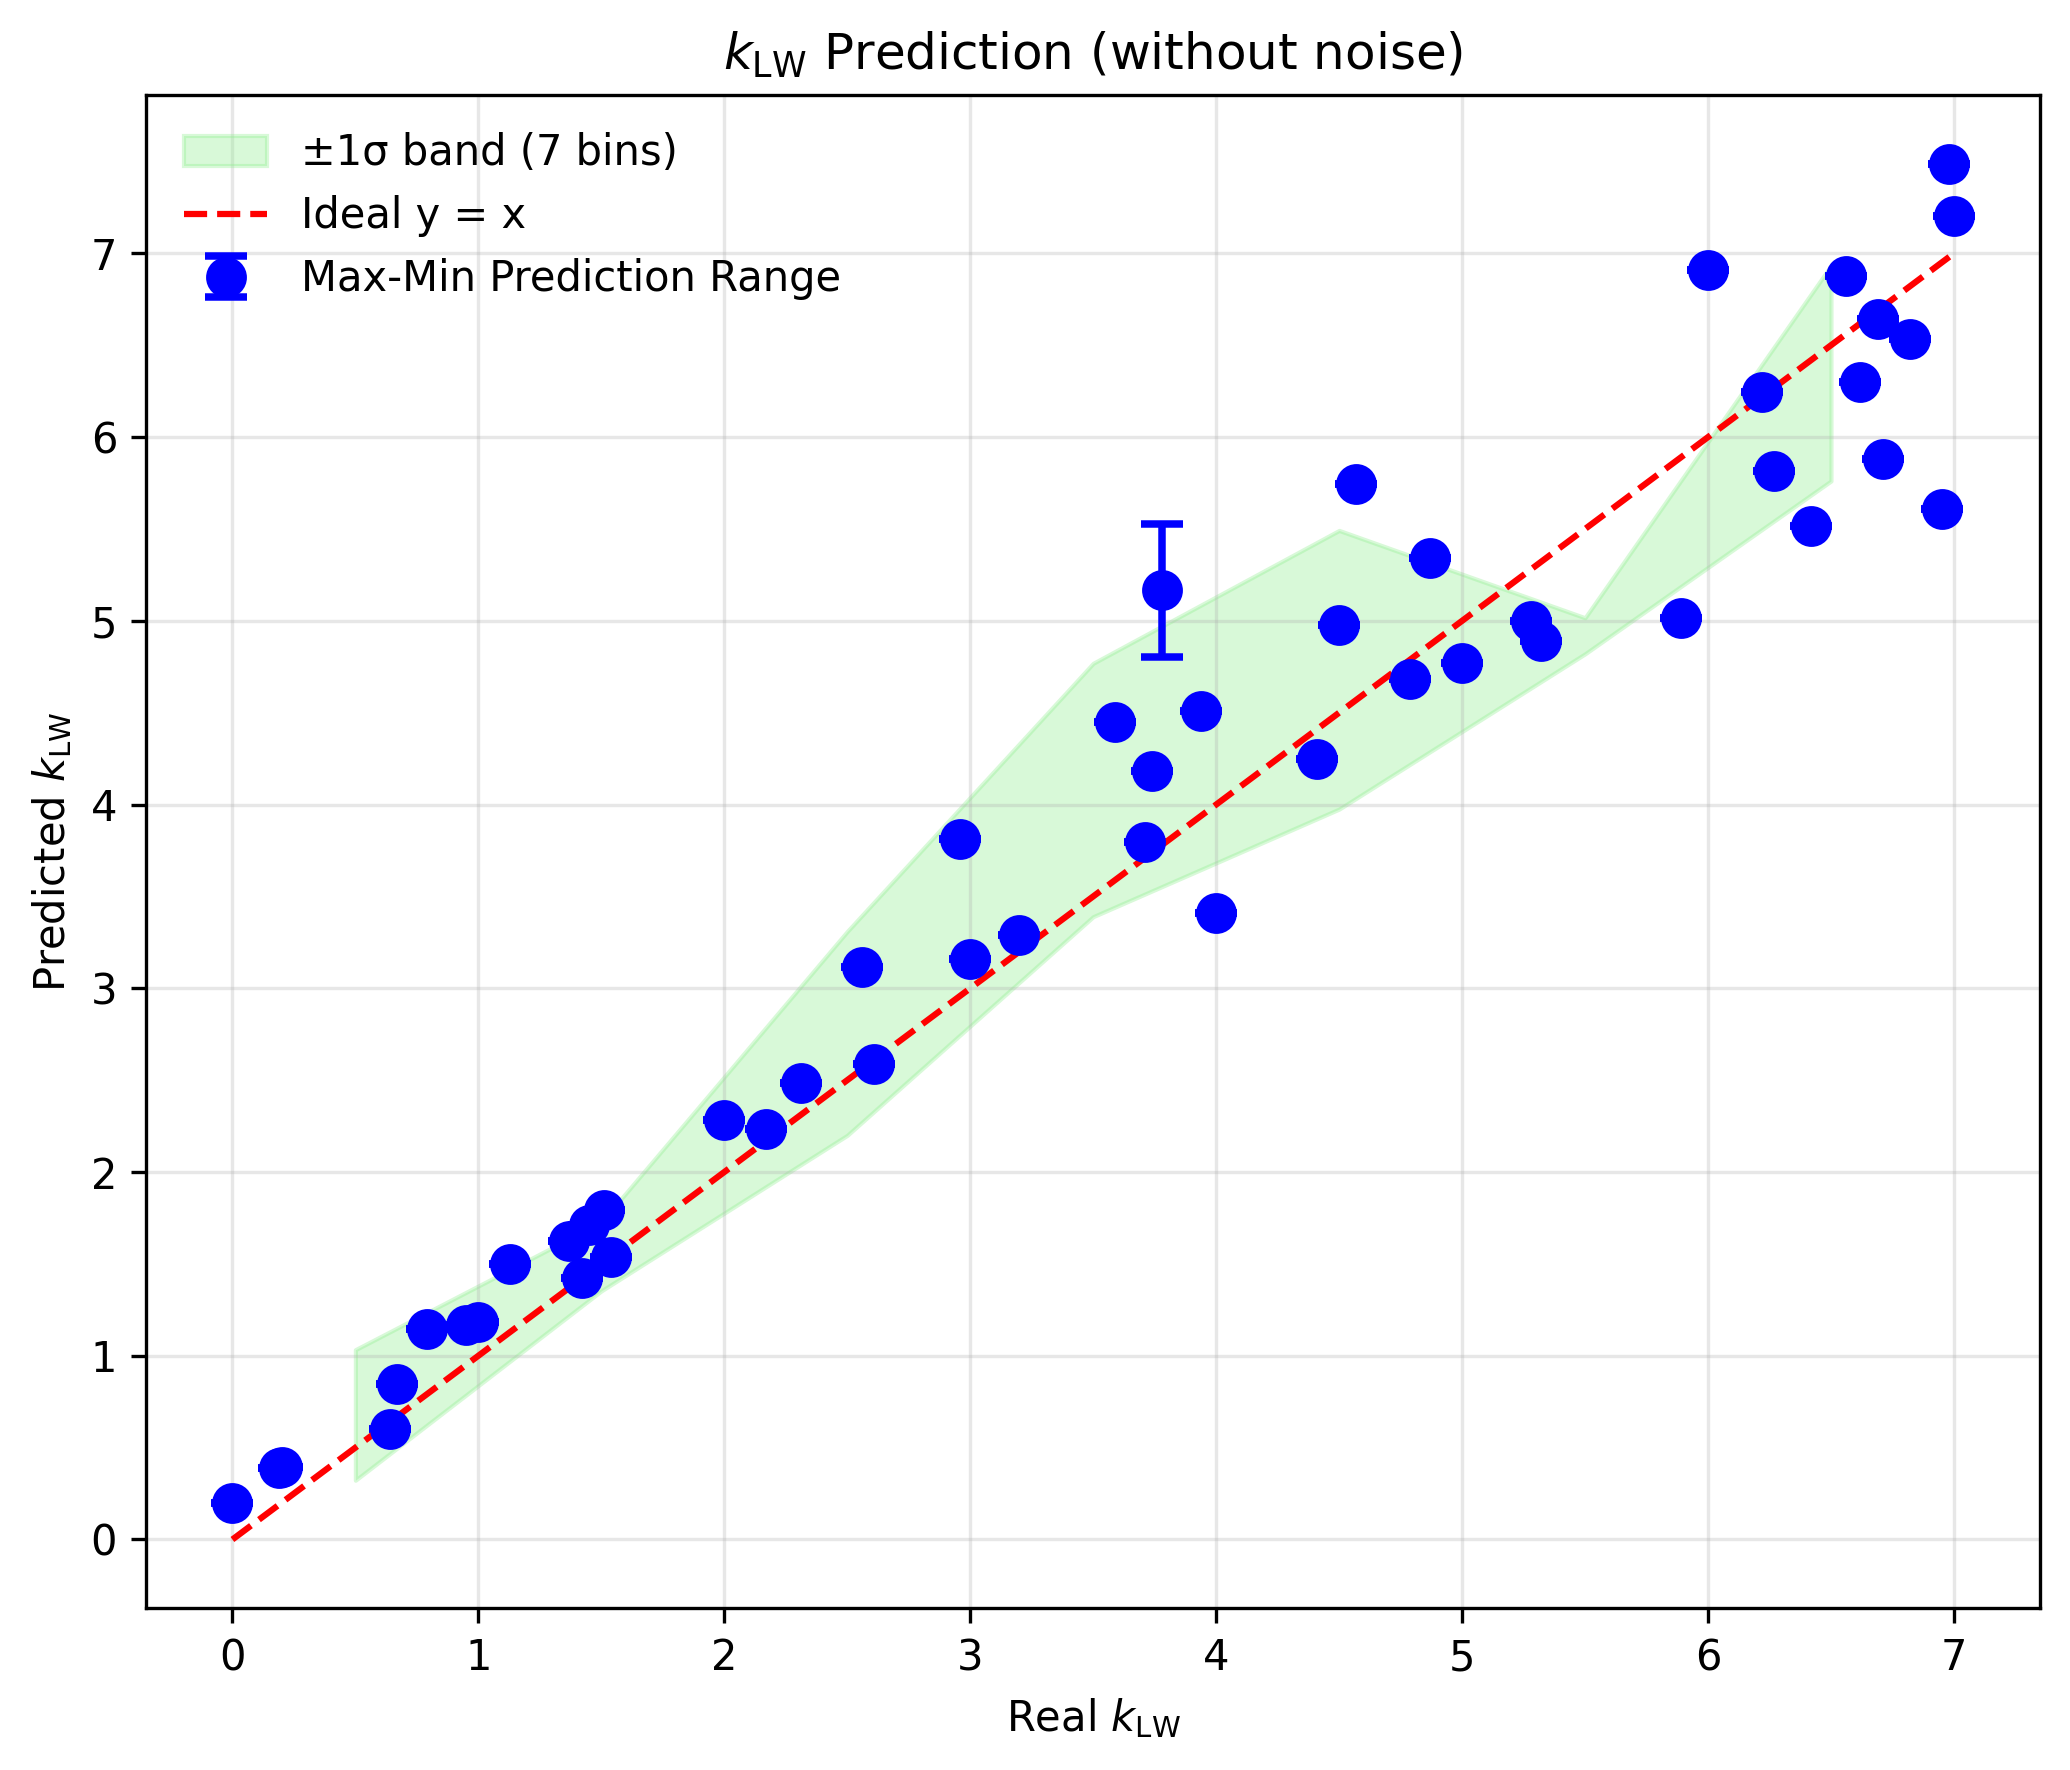

In [27]:
# ====================== 新代码块：四张独立图（Max-Min errorbar 实心中心 + 7bin 1σ色带） ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置学术风格
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 6
plt.rcParams['text.usetex'] = False

# 读取数据（文件名完全保持原样）
df_k_nonoise   = pd.read_csv("k_LW_group_stats_modelA.csv")    # 无噪音

# --------------------- 函数：绘制单张独立图（Max-Min errorbar 实心中心） ---------------------
def plot_maxmin_with_sigma_band(df, real_col, min_col, max_col, mean_col, std_col,
                                title, xlabel, ylabel, filename, use_sci=False, nbins=7):
    df_valid = df.dropna(subset=[min_col, max_col])
    
    if len(df_valid) == 0:
        print(f"警告：{filename} 无有效数据")
        return
    
    real = df_valid[real_col].values
    pred_min = df_valid[min_col].values
    pred_max = df_valid[max_col].values
    pred_mean = df_valid[mean_col].values if mean_col in df_valid else (pred_min + pred_max)/2
    pred_std = df_valid[std_col].values if std_col in df_valid else np.zeros_like(pred_min)
    
    # 创建图片
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # === 7个均匀bin的平滑 ±1σ 色带 ===
    overall_min = real.min()
    overall_max = real.max()
    bin_edges = np.linspace(overall_min, overall_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    lowers = np.full(nbins, np.nan)
    uppers = np.full(nbins, np.nan)
    
    for i in range(nbins):
        mask = (real >= bin_edges[i]) & (real < bin_edges[i+1])
        if np.sum(mask) > 1:
            bin_means = pred_mean[mask]
            bin_stds = pred_std[mask]
            combined_mean = np.mean(bin_means)
            combined_std = np.sqrt(np.mean(bin_stds**2) + np.var(bin_means))
            lowers[i] = combined_mean - combined_std
            uppers[i] = combined_mean + combined_std
    
    ax.fill_between(bin_centers, lowers, uppers, color='lightgreen', alpha=0.35, label='±1σ band (7 bins)')
    
    # === Max-Min Prediction Range errorbar（中心实心圆点）===
    mid = (pred_min + pred_max) / 2
    err = (pred_max - pred_min) / 2
    ax.errorbar(real, mid, yerr=err,
                fmt='o', color='blue', capsize=5, markersize=8,
                markerfacecolor='blue', markeredgewidth=1.8, elinewidth=1.8,  # 实心中心 + 粗边/棒
                label='Max-Min Prediction Range')
    
    # 理想线
    ax.plot([overall_min, overall_max], [overall_min, overall_max], 'r--', lw=1.5, label='Ideal y = x')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    if use_sci:
        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# --------------------- 绘制四张独立图 ---------------------

# 2. k_LW 无噪音
plot_maxmin_with_sigma_band(
    df_k_nonoise,
    real_col="k_LW_real",
    min_col="k_LW_pred_min",
    max_col="k_LW_pred_max",
    mean_col="k_LW_pred_mean",
    std_col="k_LW_pred_std",
    title="$k_{\\mathrm{LW}}$ Prediction (without noise)",
    xlabel="Real $k_{\\mathrm{LW}}$",
    ylabel="Predicted $k_{\\mathrm{LW}}$",
    filename="kLW_without_noise_maxmin_filled_modelA.png"
)

